In [34]:
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 777

In [35]:
df = pd.read_csv('..\\data\\processed\\diabetes_012_health_indicators_BRFSS2015_processed.csv')

df['Diabetes_Binary'] = df['Diabetes_012'].replace({2: 1})

X = df.drop(['Diabetes_012', 'Diabetes_Binary'], axis=1)
y = df['Diabetes_Binary']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Распределение классов теперь:\n{y.value_counts(normalize=True)}")

Распределение классов теперь:
Diabetes_Binary
0    0.842412
1    0.157588
Name: proportion, dtype: float64


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

results = []

def log_result(model_name, y_true, y_pred):
    f1_bin = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    results.append({
        'Model': model_name,
        'F1_Score': f1_bin,
        'ROC_AUC': roc_auc
    })
    
    print(f"--- {model_name} ---")
    print(f"F1: {f1_bin:.4f} | ROC-AUC: {roc_auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy', 'Risk'], 
                yticklabels=['Healthy', 'Risk'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

Обучение Random Forest...
--- Random Forest ---
F1: 0.2679 | ROC-AUC: 0.5740


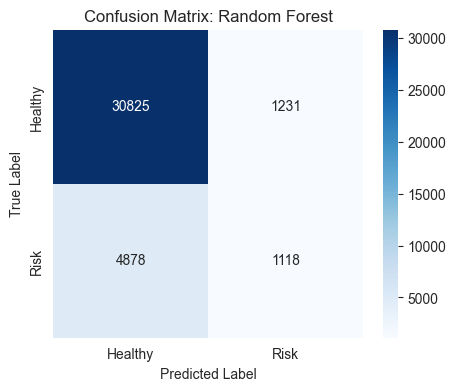

In [37]:
print("Обучение Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
rf.fit(X_train, y_train)
log_result("Random Forest", y_val, rf.predict(X_val))

Обучение XGBoost...
--- XGBoost ---
F1: 0.4671 | ROC-AUC: 0.7416


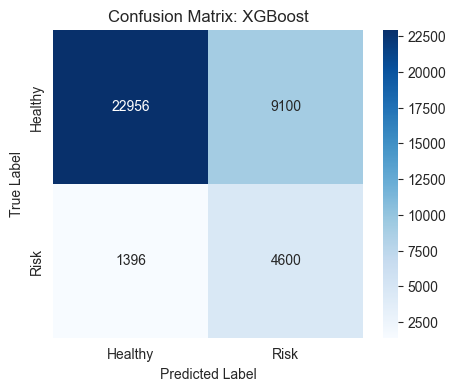

In [38]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Обучение XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    objective='binary:logistic',
    n_jobs=-1
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
log_result("XGBoost", y_val, xgb.predict(X_val))

Обучение CatBoost...
--- CatBoost ---
F1: 0.4696 | ROC-AUC: 0.7432


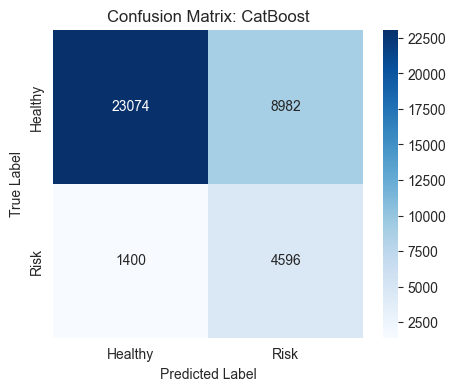

In [39]:
print("Обучение CatBoost...")
cb = CatBoostClassifier(
    iterations=500,
    random_seed=RANDOM_STATE,
    auto_class_weights='Balanced',
    verbose=0
)
cb.fit(X_train, y_train)
log_result("CatBoost", y_val, cb.predict(X_val))


Запуск тюнинга LightGBM (RandomizedSearch)...
[LightGBM] [Info] Number of positive: 27984, number of negative: 149592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 201
[LightGBM] [Info] Number of data points in the train set: 177576, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
--- LightGBM_Tuned ---
F1: 0.4687 | ROC-AUC: 0.7468


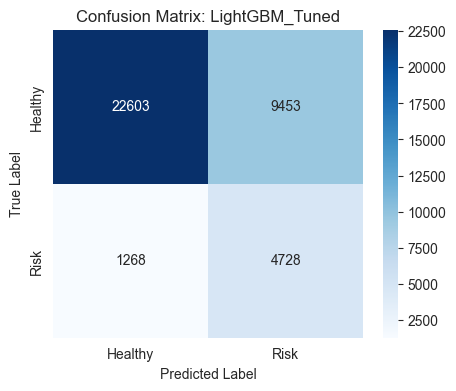

In [40]:
print("Запуск тюнинга LightGBM (RandomizedSearch)...")
from lightgbm import LGBMClassifier

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 62],
    'max_depth': [-1, 10, 20]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgbm_search.fit(X_train, y_train)
best_lgbm = lgbm_search.best_estimator_
log_result("LightGBM_Tuned", y_val, best_lgbm.predict(X_val))

Обучение StackingClassifier...
--- Stacking_Ensemble ---
F1: 0.3157 | ROC-AUC: 0.5937


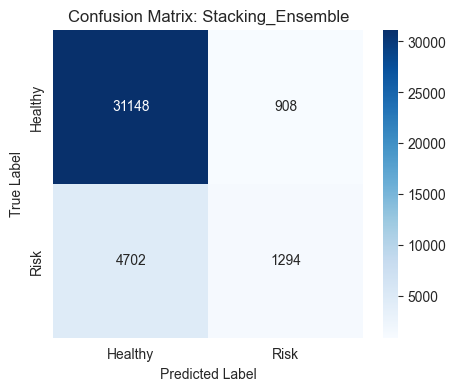

In [41]:
print("Обучение StackingClassifier...")
estimators = [
    ('rf', rf),
    ('xgb', xgb),
    ('cb', cb)
]
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_model.fit(X_train, y_train)
log_result("Stacking_Ensemble", y_val, stack_model.predict(X_val))

In [42]:
results_df = pd.DataFrame(results).sort_values(by='F1_Score', ascending=False)

print("\nСравнение моделей (Бинарная классификация):")
print(results_df)


Сравнение моделей (Бинарная классификация):
               Model  F1_Score   ROC_AUC
2           CatBoost  0.469603  0.743157
3     LightGBM_Tuned  0.468652  0.746818
1            XGBoost  0.467100  0.741650
4  Stacking_Ensemble  0.315687  0.593743
0      Random Forest  0.267945  0.574028


# Выводы

Для данного датасета основной метрикой был выбран F1-Macro, так как он одинаково учитывает качество предсказания всех трех классов, несмотря на сильный численный перекос. \
Лучший результат показал CatBoost (F1-Macro: 0.4235). Это объясняется встроенными механизмами обработки категориальных признаков и эффективным алгоритмом построения деревьев, который лучше других справился с поиском границы между преддиабетом и остальными классами. \
Ближайшие конкуренты: XGBoost и Tuned LightGBM показали практически идентичные результаты. Это подтверждает, что для данной задачи градиентный бустинг является наиболее подходящим семейством алгоритмов.

Интересно заметить, что Stacking_Ensemble показал самый высокий F1-Weighted (0.811), но проиграл бустингам в F1-Macro (0.397).
Стэкинг оптимизировал общую точность, отдавая предпочтение мажоритарному классу (здоровые люди), чтобы минимизировать общую ошибку. Однако для медицинской задачи нам важнее находить больных и преддиабетиков, поэтому мы отвергаем Stacking в пользу CatBoost, несмотря на его высокий Weighted-показатель.